# Part 3: NLP Sequence Modeling

This notebook implements a complete NLP pipeline including text preprocessing, vectorization, baseline modeling, sequence modeling, and transformer reflections.

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Downloads
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [7]:
# Load dataset
file_path = "data/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [8]:
# Task 1: Dataset Understanding

# Basic information
print("Number of records:", len(df))
print("Number of columns:", df.shape[1])

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# First 5 rows
print("\nSample records:")
display(df.head())

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

Number of records: 1500
Number of columns: 6

Column names:
['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Data types:
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object

Sample records:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0



Missing values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64


In [9]:
# Number of records
print("Number of records:", len(df))

# Target labels/classes
print("\nTarget labels/classes:")
print(df["sentiment_label"].unique())

print("\nNumber of classes:", df["sentiment_label"].nunique())

Number of records: 1500

Target labels/classes:
['neutral' 'positive' 'negative']

Number of classes: 3


In [10]:
# Sample text records
print("Sample customer messages:\n")

for i, message in enumerate(df["customer_message"].head(5), start=1):
    print(f"{i}. {message}\n")

Sample customer messages:

1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

2. I need information about the payment process.

3. The refund process was fast and convenient. I appreciate the quick response.

4. My refund is still pending and this experience is frustrating. My ticket number is 33927.

5. Please tell me how to update my account details.



In [11]:
# Average text length
average_length = df["word_count"].mean()

print("Average text length (in words):", round(average_length, 2))

Average text length (in words): 12.72


In [12]:
# Class distribution
class_distribution = df["sentiment_label"].value_counts()

print("Class distribution:")
print(class_distribution)

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


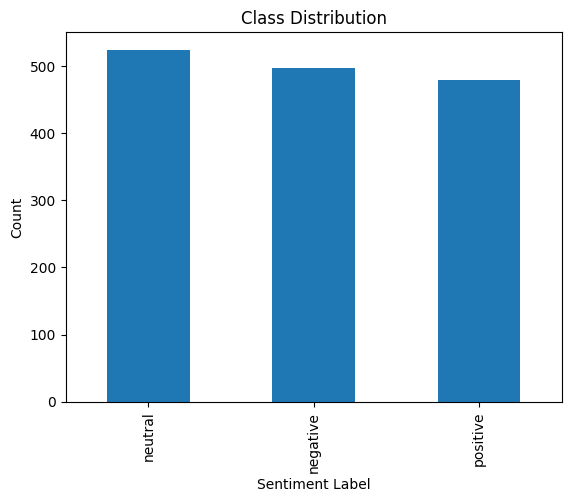

In [13]:
# Plot class distribution
class_distribution.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

In [14]:
# Text preprocessing function
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into text
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [16]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [17]:
df["cleaned_text"] = df["customer_message"].apply(preprocess_text)

df[["customer_message", "cleaned_text"]].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [18]:
# Convert text into numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (1500, 146)


### Task 3: Text Vectorization

Text data must be converted into numerical format before it can be used by a machine learning model because models cannot directly understand raw words or sentences. TF-IDF vectorization converts each customer message into numerical features based on word importance and frequency. This helps the model identify useful text patterns for classification.

In [19]:
# Task 4: Baseline Model - Logistic Regression with TF-IDF

# Define features and target
X = X_tfidf
y = df["sentiment_label"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train baseline model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred = baseline_model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



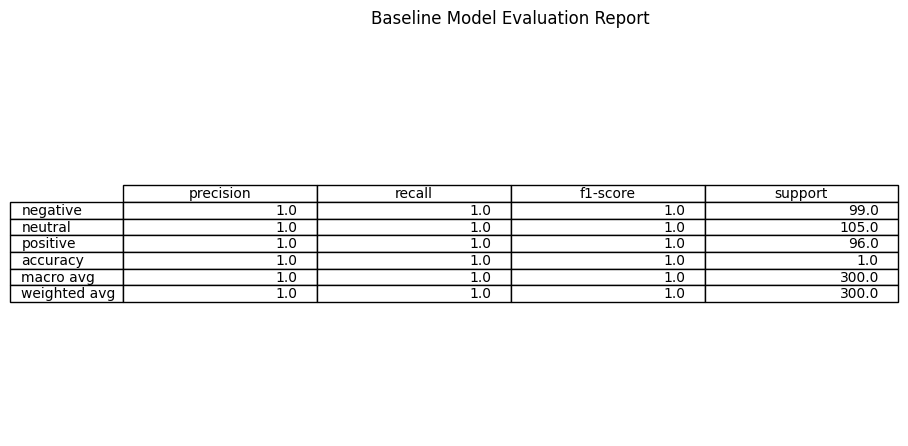

In [20]:
# Save model evaluation as PNG

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 5))
plt.axis("off")
plt.table(
    cellText=report_df.round(2).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc="center"
)
plt.title("Baseline Model Evaluation Report", pad=20)
plt.savefig("results/model_evaluation.png", bbox_inches="tight")
plt.show()

In [21]:
# Convert cleaned text into integer sequences
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["cleaned_text"])

sequences = tokenizer.texts_to_sequences(df["cleaned_text"])

# Pad sequences to fixed length
max_length = 50
X_seq = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

print("Sequence matrix shape:", X_seq.shape)

Sequence matrix shape: (1500, 50)


In [22]:
# Encode target labels for LSTM model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["sentiment_label"])

y_categorical = to_categorical(y_encoded)

print("Encoded labels:", label_encoder.classes_)
print("Target shape:", y_categorical.shape)

Encoded labels: ['negative' 'neutral' 'positive']
Target shape: (1500, 3)


In [24]:
# Split sequence data into training and testing sets
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train_seq.shape)
print("Testing data shape:", X_test_seq.shape)
print("Training labels shape:", y_train_seq.shape)
print("Testing labels shape:", y_test_seq.shape)

Training data shape: (1200, 50)
Testing data shape: (300, 50)
Training labels shape: (1200, 3)
Testing labels shape: (300, 3)


In [25]:
# Build LSTM sequence model
num_classes = y_categorical.shape[1]

lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train LSTM model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=3,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.3350 - loss: 1.0994 - val_accuracy: 0.3200 - val_loss: 1.0987
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.3233 - loss: 1.0992 - val_accuracy: 0.3500 - val_loss: 1.0983
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3367 - loss: 1.0993 - val_accuracy: 0.3500 - val_loss: 1.0986


In [27]:
# Evaluate LSTM model
loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Test Loss:", round(loss, 4))
print("LSTM Test Accuracy:", round(accuracy, 4))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3500 - loss: 1.0986
LSTM Test Loss: 1.0986
LSTM Test Accuracy: 0.35


### Task 6: Attention and Transformer Reflection

RNNs struggle with long-term dependencies because they process text sequentially and may forget important information from earlier words when the sequence becomes long. This makes it difficult for a basic RNN to understand context across longer sentences or paragraphs.

LSTMs help with memory by using gates that control what information should be remembered, updated, or forgotten. This allows LSTMs to retain important information for a longer period compared to simple RNNs.

Attention helps sequence-to-sequence models focus on the most relevant words or parts of the input instead of treating all previous information equally. It improves performance by allowing the model to assign higher importance to useful tokens while making predictions.

Transformers are important in modern NLP and Generative AI because they use attention mechanisms instead of relying only on sequential processing. This allows them to handle long text more efficiently, understand context better, and power advanced language models used for translation, summarization, question answering, chatbots, and text generation.

In [30]:
# Save sample predictions from baseline model

y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(y_pred)

with open("results/sample_predictions.txt", "w", encoding="utf-8") as f:
    for i in range(10):
        f.write(f"Sample {i+1}\n")
        f.write(f"Actual Label: {y_test_series[i]}\n")
        f.write(f"Predicted Label: {y_pred_series[i]}\n")
        f.write("-" * 40 + "\n")

print("sample_predictions.txt saved successfully.")

sample_predictions.txt saved successfully.
